In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Iniciando la descarga del Dataset M4...")

# 1. URLs oficiales del repositorio de la competencia M4
url_info = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/M4-info.csv"
url_train = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Train/Monthly-train.csv"

# 2. Cargar metadatos y filtrar por Finanzas y Frecuencia Mensual
m4_info = pd.read_csv(url_info)
finance_monthly_info = m4_info[(m4_info['category'] == 'Finance') & (m4_info['SP'] == 'Monthly')]

# Extraer los IDs de las series que nos interesan (ej. M1, M2, M3...)
finance_ids = finance_monthly_info['M4id'].values
print(f"Total de series Financieras Mensuales identificadas: {len(finance_ids)}")

# 3. Cargar el dataset de entrenamiento
print("Descargando serie histórica de entrenamiento (Monthly-train.csv). Esto puede tomar unos segundos...")
train_df = pd.read_csv(url_train)

# Renombrar la primera columna a 'M4id' para cruzar los datos
train_df.rename(columns={'V1': 'M4id'}, inplace=True)

# 4. Filtrar la matriz de datos para quedarnos SOLO con las series financieras
finance_data = train_df[train_df['M4id'].isin(finance_ids)].set_index('M4id')

print(f"Dimensiones del dataset de finanzas filtrado: {finance_data.shape[0]} series x {finance_data.shape[1]} meses máximos.")

Iniciando la descarga del Dataset M4...
Total de series Financieras Mensuales identificadas: 10987
Descargando serie histórica de entrenamiento (Monthly-train.csv). Esto puede tomar unos segundos...
Dimensiones del dataset de finanzas filtrado: 10987 series x 2794 meses máximos.


#ANALISIS DE DATOS (EDA)

Se realizara el analisis para poder tomar series temporales que tengan mas de 72 meses (6 años) un umbral bueno para poder entrenar nuestros modelos


--- ESTADÍSTICAS BÁSICAS DE LONGITUD ---
count    10987.000000
mean       183.942842
std        116.141928
min         60.000000
25%         74.000000
50%        175.000000
75%        237.000000
max       1502.000000
Name: Actual_Length, dtype: float64


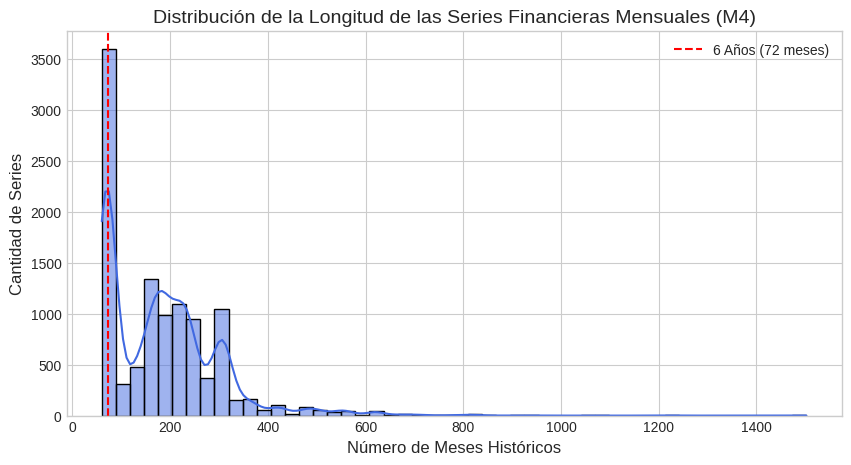

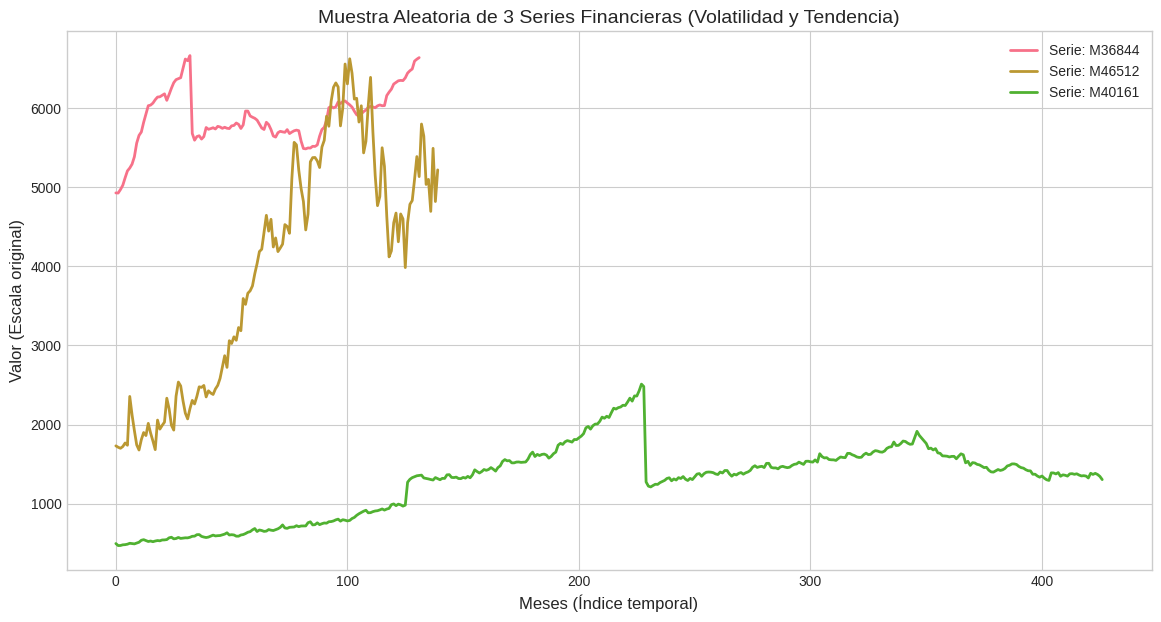

In [5]:
# --- INICIO DEL EDA ---

# 1. Calcular la longitud real de cada serie (descartando los valores nulos/NaN al final)
# En el M4, los datos faltantes al final de la matriz aparecen como NaN
series_lengths = finance_data.notna().sum(axis=1)

# Añadir la longitud al dataframe de información
finance_monthly_info = finance_monthly_info.set_index('M4id')
finance_monthly_info['Actual_Length'] = series_lengths

print("\n--- ESTADÍSTICAS BÁSICAS DE LONGITUD ---")
print(finance_monthly_info['Actual_Length'].describe())

# 2. Gráfico de distribución de longitudes
plt.figure(figsize=(10, 5))
sns.histplot(finance_monthly_info['Actual_Length'], bins=50, kde=True, color='royalblue')
plt.title('Distribución de la Longitud de las Series Financieras Mensuales (M4)', fontsize=14)
plt.xlabel('Número de Meses Históricos', fontsize=12)
plt.ylabel('Cantidad de Series', fontsize=12)
plt.axvline(x=72, color='red', linestyle='--', label='6 Años (72 meses)')
plt.legend()
plt.show()

# 3. Visualizar el comportamiento de 3 series aleatorias para entender su volatilidad
np.random.seed(42) # Para reproducibilidad
sample_series = np.random.choice(finance_data.index, 3, replace=False)

plt.figure(figsize=(14, 7))
for series_id in sample_series:
    # Extraer los datos, quitar los NaNs
    y = finance_data.loc[series_id].dropna().values
    plt.plot(y, label=f'Serie: {series_id}', linewidth=2)

plt.title('Muestra Aleatoria de 3 Series Financieras (Volatilidad y Tendencia)', fontsize=14)
plt.xlabel('Meses (Índice temporal)', fontsize=12)
plt.ylabel('Valor (Escala original)', fontsize=12)
plt.legend()
plt.show()

El Percentil 25% (74 meses): Este es el dato más crítico y el más favorable. Nos indica que más del 75% del dataset (aproximadamente más de 8,200 empresas o métricas) tiene al menos 74 meses de historia (más de 6 años). Esto nos garantiza suficiente profundidad para entrenar modelos de Deep Learning (como N-BEATS) y dejar una ventana de 18 meses para validación.

La Mediana (175 meses): El 50% del dataset tiene casi 15 años de historia mensual. Esto es excelente para que la IA aprenda ciclos económicos de largo plazo y variables macroeconómicas.

El Histograma y el Pico de los 60-70 meses: La gráfica muestra una altísima concentración de series justo en el umbral que nos interesa. Las empresas suelen estandarizar sus sistemas ERP o procesos de FP&A en bloques de 5 años (60 meses), lo que explica ese gran pico en la distribución.

<br><br>

Dado que el percentil 25% está en 74, fijaremos nuestro umbral de corte estrictamente en 72 meses (6 años de historia). Cualquier serie con menos de 72 meses será descartada. Esto asegura que para cada serie tendrás, como mínimo:

*  Ventana de Entrenamiento: 54 meses (4.5 años) para que el modelo aprenda la estacionalidad anual repetida.

*  Ventana de Test (Backtesting): 18 meses (1.5 años), que es el estándar oficial de previsión de la competencia M4 para frecuencia mensual.

#Preprocesamiento y Particionamiento (Walk-Forward Split)

In [6]:
# --- FASE 3: FILTRADO Y PARTICIONAMIENTO TEMPORAL ---

# 1. Definir la longitud de pronóstico (Horizonte M4 Mensual = 18 meses)
HORIZONTE_PREDICCION = 18
UMBRAL_MINIMO = 72

print("--- INICIANDO PREPROCESAMIENTO ---")

# 2. Filtrar las series que cumplan con la condición de longitud
series_validas = finance_monthly_info[finance_monthly_info['Actual_Length'] >= UMBRAL_MINIMO].index
finance_data_filtered = finance_data.loc[series_validas]

print(f"Series originales: {finance_data.shape[0]}")
print(f"Series retenidas (>= {UMBRAL_MINIMO} meses): {finance_data_filtered.shape[0]}")
print(f"Porcentaje retenido: {(finance_data_filtered.shape[0] / finance_data.shape[0]) * 100:.1f}%\n")

# 3. Función para realizar el split Walk-Forward de forma segura (sin Data Leakage)
def walk_forward_split(df_filtered, horizon):
    """
    Divide cada serie en Train y Test.
    Test toma los últimos 'horizon' meses reales.
    Train toma todo el historial anterior.
    """
    X_train_list = []
    y_test_list = []

    # Iterar sobre cada serie (es rápido usando iterrows o apply, aquí usamos un loop claro)
    for index, row in df_filtered.iterrows():
        # Extraer valores reales quitando los NaNs finales
        serie_real = row.dropna().values

        # Partición estricta
        train = serie_real[:-horizon]
        test = serie_real[-horizon:]

        X_train_list.append(train)
        y_test_list.append(test)

    return X_train_list, y_test_list

# 4. Ejecutar el particionamiento
X_train, y_test = walk_forward_split(finance_data_filtered, HORIZONTE_PREDICCION)

print("--- PARTICIONAMIENTO COMPLETADO ---")
print(f"Ejemplo Serie 0 - Longitud de Entrenamiento: {len(X_train[0])} meses")
print(f"Ejemplo Serie 0 - Longitud de Test: {len(y_test[0])} meses (Horizonte fijo)")

--- INICIANDO PREPROCESAMIENTO ---
Series originales: 10987
Series retenidas (>= 72 meses): 8493
Porcentaje retenido: 77.3%

--- PARTICIONAMIENTO COMPLETADO ---
Ejemplo Serie 0 - Longitud de Entrenamiento: 336 meses
Ejemplo Serie 0 - Longitud de Test: 18 meses (Horizonte fijo)


Para datos financieros de frecuencia mensual, el estándar de oro como baseline es el Seasonal Naïve (Naïve Estacional).

*  La premisa: Este modelo asume que el valor de un mes en el futuro será exactamente igual al valor de ese mismo mes en el año anterior (ej. las ventas de diciembre de 2024 serán iguales a las de diciembre de 2023).

*  El objetivo: Cualquier modelo de Machine Learning (como LightGBM) o Deep Learning (como N-BEATS) que construyamos en los siguientes pasos debe superar obligatoriamente el error de este baseline. Si un modelo complejo no puede ganarle a esta regla tan simple, se descarta por ineficiente.

Vamos a implementar el cálculo de nuestra primera métrica técnica (el sMAPE - Error Porcentual Absoluto Medio Simétrico) y el modelo.

--- INICIANDO MODELO BASELINE: SEASONAL NAÏVE ---
Número de series evaluadas: 8493
sMAPE Promedio Global (Baseline): 14.45%



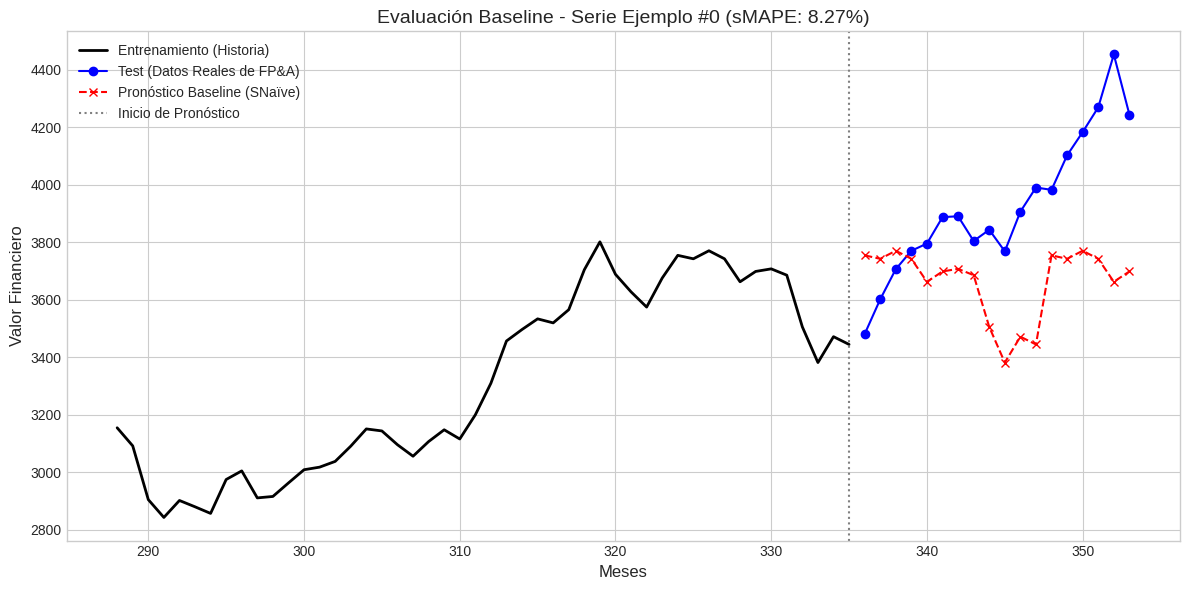

In [7]:
import numpy as np
import matplotlib.pyplot as plt

print("--- INICIANDO MODELO BASELINE: SEASONAL NAÏVE ---")

# 1. Definición de la métrica sMAPE (Estándar de la competencia M4)
def calculate_smape(y_true, y_pred):
    """
    Calcula el sMAPE entre los valores reales y las predicciones.
    Retorna el porcentaje de error (0% a 200%).
    """
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0

    # Evitar división por cero
    denominator = np.where(denominator == 0, 1e-8, denominator)

    return np.mean(numerator / denominator) * 100

# 2. Definición del Modelo Seasonal Naïve
def seasonal_naive_forecast(history, horizon, seasonality=12):
    """
    Pronostica repitiendo el último patrón estacional conocido.
    Para datos mensuales, seasonality = 12.
    """
    # Tomamos los últimos 12 meses de la historia (X_train)
    last_season = history[-seasonality:]

    # Repetimos ese patrón suficientes veces para cubrir los 18 meses (horizonte)
    reps = int(np.ceil(horizon / seasonality))
    forecast = np.tile(last_season, reps)[:horizon]

    return forecast

# 3. Ejecutar el pronóstico sobre todas las series (Backtesting de 1 ventana)
smapes_baseline = []
predicciones_baseline = []

# Recorremos todas nuestras series financieras
for i in range(len(X_train)):
    historia = X_train[i]
    valores_reales = y_test[i]

    # Generar predicción (18 meses)
    prediccion = seasonal_naive_forecast(historia, horizon=HORIZONTE_PREDICCION, seasonality=12)
    predicciones_baseline.append(prediccion)

    # Calcular y guardar el error
    error_smape = calculate_smape(valores_reales, prediccion)
    smapes_baseline.append(error_smape)

# 4. Resultados Globales
smape_promedio_baseline = np.mean(smapes_baseline)
print(f"Número de series evaluadas: {len(X_train)}")
print(f"sMAPE Promedio Global (Baseline): {smape_promedio_baseline:.2f}%\n")

# 5. Visualización del Baseline para una serie de ejemplo (Serie 0)
serie_idx = 0
historia_ejemplo = X_train[serie_idx]
real_ejemplo = y_test[serie_idx]
pred_ejemplo = predicciones_baseline[serie_idx]

# Crear un eje de tiempo para la gráfica
tiempo_historia = np.arange(len(historia_ejemplo))
tiempo_test = np.arange(len(historia_ejemplo), len(historia_ejemplo) + HORIZONTE_PREDICCION)

plt.figure(figsize=(12, 6))
# Graficar solo los últimos 48 meses de historia para que se vea claro el empalme
zoom = 48
plt.plot(tiempo_historia[-zoom:], historia_ejemplo[-zoom:], label='Entrenamiento (Historia)', color='black', linewidth=2)
plt.plot(tiempo_test, real_ejemplo, label='Test (Datos Reales de FP&A)', color='blue', marker='o')
plt.plot(tiempo_test, pred_ejemplo, label='Pronóstico Baseline (SNaïve)', color='red', linestyle='--', marker='x')

plt.title(f'Evaluación Baseline - Serie Ejemplo #{serie_idx} (sMAPE: {smapes_baseline[serie_idx]:.2f}%)', fontsize=14)
plt.xlabel('Meses', fontsize=12)
plt.ylabel('Valor Financiero', fontsize=12)
plt.axvline(x=len(historia_ejemplo)-1, color='gray', linestyle=':', label='Inicio de Pronóstico')
plt.legend()
plt.tight_layout()
plt.show()

#Machine Learning (PIPELINE LIGHTGBM)
El Paradigma: De Series Temporales a Datos Tabulares (Global Forecasting)
A diferencia del Naïve o ARIMA que analizan una serie a la vez, LightGBM no "entiende" el tiempo por defecto. Necesitamos transformar tus series en una matriz de datos tradicional (filas y columnas) creando rezagos (lags). Además, aplicaremos la técnica de Global Forecasting que mencionabas en tus documentos: entrenaremos un único y masivo modelo LightGBM con el historial de las 8,493 empresas juntas.

Para que un modelo global funcione, es obligatorio escalar los datos, de lo contrario, la empresa que factura millones aplastará a la que factura miles en el entrenamiento.

--- INICIANDO PIPELINE LIGHTGBM GLOBAL ---
1. Escalando y creando matriz tabular global...
Dimensiones de la matriz de entrenamiento: 1496573 filas x 24 lags
2. Entrenando LightGBM (Esto tomará unos segundos)...
3. Ejecutando pronóstico recursivo en test...

--- RESULTADOS FINALES ---
sMAPE Promedio Global (LightGBM): 12.73%


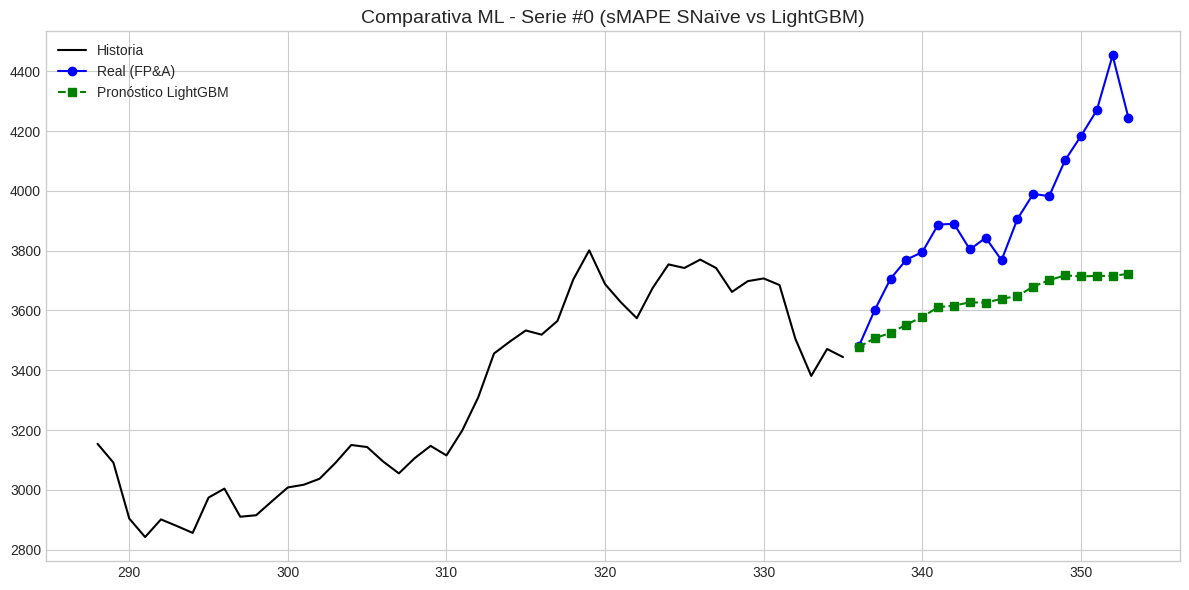

In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

print("--- INICIANDO PIPELINE LIGHTGBM GLOBAL ---")

# 1. Hiperparámetros de la ventana
# Usaremos 24 meses (2 años) de historia como "features" para predecir el mes 25
LAGS = 24
HORIZONTE_PREDICCION = 18

# --- FASE 1: PREPROCESAMIENTO Y TABULACIÓN (GLOBAL) ---
print("1. Escalando y creando matriz tabular global...")

X_train_global = []
y_train_global = []
scalers = [] # Para guardar factores de escala y revertir después

# Iteramos sobre los datos de entrenamiento que ya teníamos limpios
for i, serie_historia in enumerate(X_train):
    # a. Escalado MaxAbs (Robusto para series sin distorsionar el cero)
    max_val = np.max(np.abs(serie_historia))
    if max_val == 0: max_val = 1.0 # Evitar división por cero
    scalers.append(max_val)

    serie_escalada = serie_historia / max_val

    # b. Creación de Lags (Ventanas deslizantes)
    # Ejemplo: Si la serie tiene 100 meses, creamos ventanas de 24 meses para predecir el mes 25
    for t in range(len(serie_escalada) - LAGS):
        X_train_global.append(serie_escalada[t : t + LAGS])
        y_train_global.append(serie_escalada[t + LAGS])

X_train_global = np.array(X_train_global)
y_train_global = np.array(y_train_global)

print(f"Dimensiones de la matriz de entrenamiento: {X_train_global.shape[0]} filas x {X_train_global.shape[1]} lags")

# --- FASE 2: ENTRENAMIENTO DEL MODELO GLOBAL ---
print("2. Entrenando LightGBM (Esto tomará unos segundos)...")

# Configuración básica pero robusta para regresión
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

train_data = lgb.Dataset(X_train_global, label=y_train_global)
modelo_lgb = lgb.train(params, train_data, num_boost_round=150)

# --- FASE 3: INFERENCIA RECURSIVA Y EVALUACIÓN ---
print("3. Ejecutando pronóstico recursivo en test...")

predicciones_lgb = []
smapes_lgb = []

# Función sMAPE reciclada del Baseline
def calculate_smape(y_true, y_pred):
    numerador = np.abs(y_true - y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominador = np.where(denominador == 0, 1e-8, denominador)
    return np.mean(numerador / denominador) * 100

for i in range(len(X_train)):
    historia = X_train[i]
    real = y_test[i]
    escala = scalers[i]

    # Tomamos los últimos 'LAGS' meses conocidos de la historia y los escalamos
    ultimos_datos = (historia[-LAGS:] / escala).tolist()
    prediccion_serie = []

    # Predicción recursiva: predecimos 1 mes, lo agregamos a la historia, predecimos el siguiente...
    for h in range(HORIZONTE_PREDICCION):
        # Convertir a formato que espera LightGBM (1 fila, 'LAGS' columnas)
        x_input = np.array(ultimos_datos[-LAGS:]).reshape(1, -1)
        pred_mes = modelo_lgb.predict(x_input)[0]

        prediccion_serie.append(pred_mes)
        ultimos_datos.append(pred_mes) # Alimentar el modelo con su propia predicción

    # Revertir escalado
    prediccion_serie = np.array(prediccion_serie) * escala
    predicciones_lgb.append(prediccion_serie)

    # Calcular error
    smapes_lgb.append(calculate_smape(real, prediccion_serie))

# --- RESULTADOS ---
smape_promedio_lgb = np.mean(smapes_lgb)
print(f"\n--- RESULTADOS FINALES ---")
print(f"sMAPE Promedio Global (LightGBM): {smape_promedio_lgb:.2f}%")

# Gráfico comparativo de la Serie 0
serie_idx = 0
plt.figure(figsize=(12, 6))
tiempo_historia = np.arange(len(X_train[serie_idx]))
tiempo_test = np.arange(len(X_train[serie_idx]), len(X_train[serie_idx]) + HORIZONTE_PREDICCION)

zoom = 48
plt.plot(tiempo_historia[-zoom:], X_train[serie_idx][-zoom:], label='Historia', color='black')
plt.plot(tiempo_test, y_test[serie_idx], label='Real (FP&A)', color='blue', marker='o')
plt.plot(tiempo_test, predicciones_lgb[serie_idx], label='Pronóstico LightGBM', color='green', linestyle='--', marker='s')

plt.title(f'Comparativa ML - Serie #{serie_idx} (sMAPE SNaïve vs LightGBM)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Optimizando los en PIPELINE LIGHTGBM GLOBAL

--- INICIANDO PIPELINE LIGHTGBM GLOBAL (OPTIMIZADO) ---
1. Escalando y creando matriz tabular global (LAGS=36)...
Dimensiones de la matriz: 1394657 filas x 36 lags
2. Entrenando LightGBM Optimizado (Esto tomará un poco más de tiempo)...
3. Ejecutando pronóstico recursivo en test...

--- RESULTADOS DE LA OPTIMIZACIÓN ---
sMAPE Anterior (LightGBM Base): 12.73%
sMAPE Nuevo (LightGBM Optimizado): 12.48%


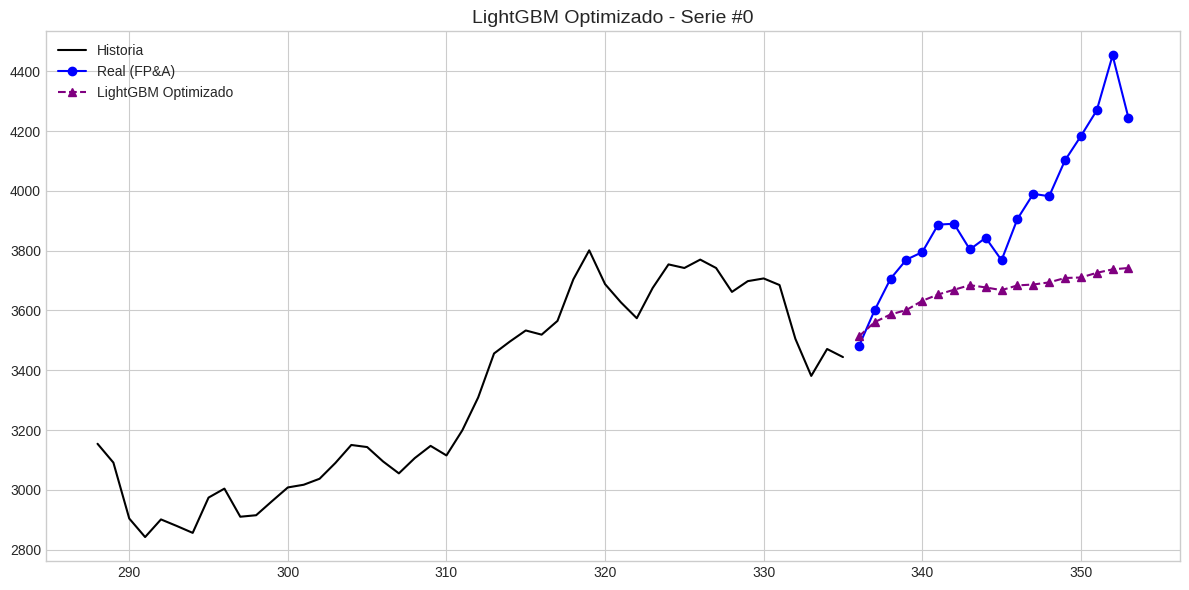

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

print("--- INICIANDO PIPELINE LIGHTGBM GLOBAL (OPTIMIZADO) ---")

# 1. Hiperparámetros de la ventana (Memoria de 3 años)
LAGS = 36
HORIZONTE_PREDICCION = 18

# --- FASE 1: PREPROCESAMIENTO Y TABULACIÓN ---
print("1. Escalando y creando matriz tabular global (LAGS=36)...")

X_train_global = []
y_train_global = []
scalers = []

for i, serie_historia in enumerate(X_train):
    max_val = np.max(np.abs(serie_historia))
    if max_val == 0: max_val = 1.0
    scalers.append(max_val)

    serie_escalada = serie_historia / max_val

    for t in range(len(serie_escalada) - LAGS):
        X_train_global.append(serie_escalada[t : t + LAGS])
        y_train_global.append(serie_escalada[t + LAGS])

X_train_global = np.array(X_train_global)
y_train_global = np.array(y_train_global)

print(f"Dimensiones de la matriz: {X_train_global.shape[0]} filas x {X_train_global.shape[1]} lags")

# --- FASE 2: ENTRENAMIENTO DEL MODELO OPTIMIZADO ---
print("2. Entrenando LightGBM Optimizado (Esto tomará un poco más de tiempo)...")

params_opt = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,    # Aprendizaje más lento
    'num_leaves': 20,         # Menos hojas para evitar overfitting
    'max_depth': 6,           # Árboles menos profundos
    'feature_fraction': 0.8,  # Regularización de columnas
    'bagging_fraction': 0.8,  # Regularización de filas
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

train_data = lgb.Dataset(X_train_global, label=y_train_global)
# Aumentamos las rondas porque bajamos el learning_rate
modelo_lgb_opt = lgb.train(params_opt, train_data, num_boost_round=800)

# --- FASE 3: INFERENCIA RECURSIVA Y EVALUACIÓN ---
print("3. Ejecutando pronóstico recursivo en test...")

predicciones_lgb_opt = []
smapes_lgb_opt = []

def calculate_smape(y_true, y_pred):
    numerador = np.abs(y_true - y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominador = np.where(denominador == 0, 1e-8, denominador)
    return np.mean(numerador / denominador) * 100

for i in range(len(X_train)):
    historia = X_train[i]
    real = y_test[i]
    escala = scalers[i]

    ultimos_datos = (historia[-LAGS:] / escala).tolist()
    prediccion_serie = []

    for h in range(HORIZONTE_PREDICCION):
        x_input = np.array(ultimos_datos[-LAGS:]).reshape(1, -1)
        pred_mes = modelo_lgb_opt.predict(x_input)[0]

        prediccion_serie.append(pred_mes)
        ultimos_datos.append(pred_mes)

    prediccion_serie = np.array(prediccion_serie) * escala
    predicciones_lgb_opt.append(prediccion_serie)
    smapes_lgb_opt.append(calculate_smape(real, prediccion_serie))

# --- RESULTADOS FINALES ---
smape_promedio_lgb_opt = np.mean(smapes_lgb_opt)
print(f"\n--- RESULTADOS DE LA OPTIMIZACIÓN ---")
print(f"sMAPE Anterior (LightGBM Base): 12.73%")
print(f"sMAPE Nuevo (LightGBM Optimizado): {smape_promedio_lgb_opt:.2f}%")

# Gráfico comparativo de la Serie 0
serie_idx = 0
plt.figure(figsize=(12, 6))
tiempo_historia = np.arange(len(X_train[serie_idx]))
tiempo_test = np.arange(len(X_train[serie_idx]), len(X_train[serie_idx]) + HORIZONTE_PREDICCION)

zoom = 48
plt.plot(tiempo_historia[-zoom:], X_train[serie_idx][-zoom:], label='Historia', color='black')
plt.plot(tiempo_test, y_test[serie_idx], label='Real (FP&A)', color='blue', marker='o')
plt.plot(tiempo_test, predicciones_lgb_opt[serie_idx], label='LightGBM Optimizado', color='purple', linestyle='--', marker='^')

plt.title(f'LightGBM Optimizado - Serie #{serie_idx}', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

#Deep Learning
El Argumento Académico: ¿Por qué Deep Learning ahora?

LightGBM tenía un defecto de diseño estructural para este problema: el error acumulativo por recursividad. Al predecir el mes 18, LightGBM se basaba en 17 predicciones previas (y sus respectivos errores).

Las Redes Neuronales Profundas nos permiten aplicar Direct Forecasting (Pronóstico Directo). Es decir, diseñaremos una arquitectura con 36 neuronas de entrada (nuestros 3 años de historia) y exactamente 18 neuronas de salida. La red escupirá los 18 meses del horizonte futuro de un solo golpe, eliminando por completo la acumulación de error.

Vamos a implementar una arquitectura fundacional de Deep Learning (un Multi-Layer Perceptron o MLP Global) utilizando PyTorch. Es el primer paso natural antes de saltar a arquitecturas titánicas como N-BEATS.

--- INICIANDO PIPELINE DE DEEP LEARNING (DIRECT FORECASTING) ---
1. Creando tensores globales para PyTorch (36 meses -> 18 meses)...
Muestras de entrenamiento generadas: 1250276
2. Construyendo la Red Neuronal Profunda...
3. Entrenando la red por 30 épocas...
  Época [5/30], Error de Entrenamiento (MAE): 0.0506
  Época [10/30], Error de Entrenamiento (MAE): 0.0498
  Época [15/30], Error de Entrenamiento (MAE): 0.0494
  Época [20/30], Error de Entrenamiento (MAE): 0.0491
  Época [25/30], Error de Entrenamiento (MAE): 0.0489
  Época [30/30], Error de Entrenamiento (MAE): 0.0486
4. Ejecutando backtesting y evaluando en Test...

--- RESULTADOS DEL DEEP LEARNING ---
sMAPE Baseline SNaïve: 14.45%
sMAPE LightGBM Optimizado: 12.48%
sMAPE Nuevo (Deep Learning PyTorch): 15.42%


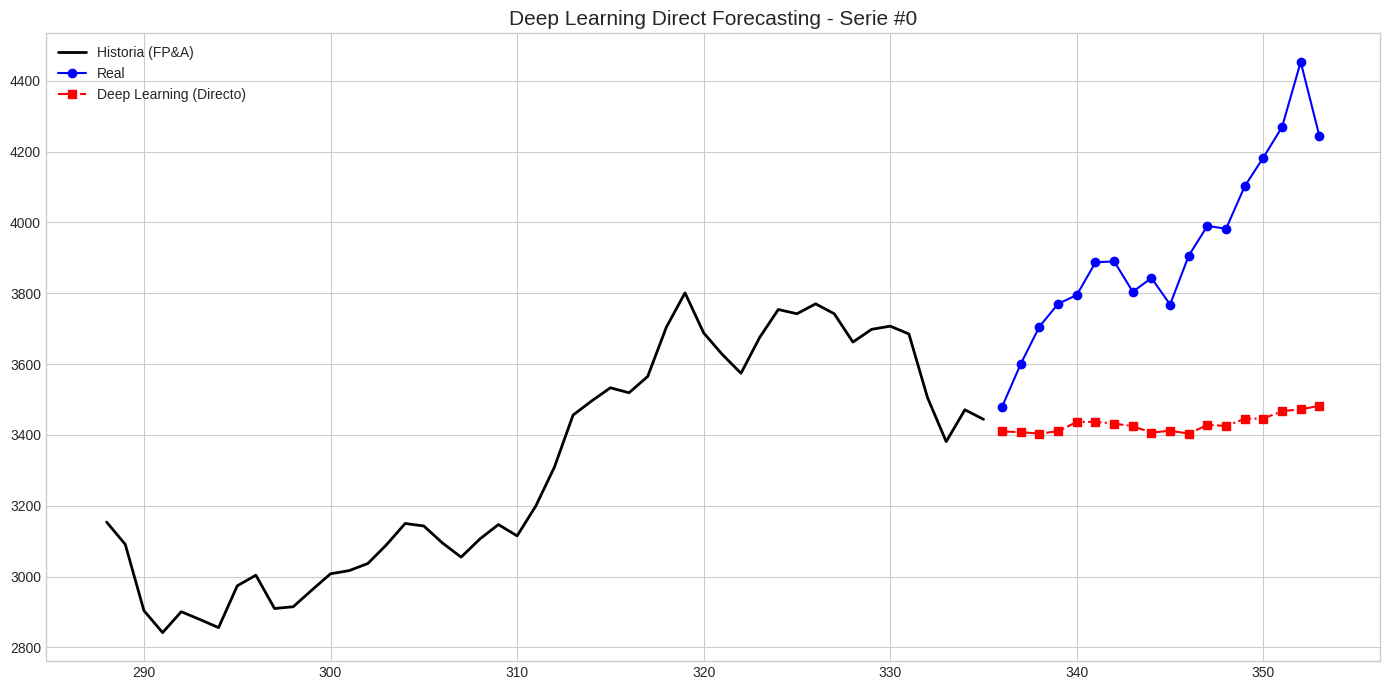

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

print("--- INICIANDO PIPELINE DE DEEP LEARNING (DIRECT FORECASTING) ---")

# 1. Parámetros de la Red
LAGS = 36
HORIZONTE_PREDICCION = 18
BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 0.001

# --- FASE 1: PREPARACIÓN DE DATOS (VENTANAS MULTI-OUTPUT) ---
print("1. Creando tensores globales para PyTorch (36 meses -> 18 meses)...")

X_train_dl = []
y_train_dl = []

# Reutilizamos los scalers del paso anterior
for i, serie_historia in enumerate(X_train):
    escala = scalers[i]
    serie_escalada = serie_historia / escala

    # Ventana deslizante para Direct Forecasting
    # Necesitamos al menos LAGS + HORIZONTE meses para crear una muestra válida
    if len(serie_escalada) >= LAGS + HORIZONTE_PREDICCION:
        for t in range(len(serie_escalada) - LAGS - HORIZONTE_PREDICCION + 1):
            X_train_dl.append(serie_escalada[t : t + LAGS])
            # El "target" ahora son 18 valores futuros, no solo 1
            y_train_dl.append(serie_escalada[t + LAGS : t + LAGS + HORIZONTE_PREDICCION])

X_train_tensor = torch.tensor(np.array(X_train_dl), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train_dl), dtype=torch.float32)

print(f"Muestras de entrenamiento generadas: {X_train_tensor.shape[0]}")

# Crear DataLoaders para entrenamiento en lotes (Batches)
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- FASE 2: DEFINICIÓN DE LA ARQUITECTURA (PyTorch) ---
print("2. Construyendo la Red Neuronal Profunda...")

class GlobalMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GlobalMLP, self).__init__()
        # Arquitectura profunda básica: 3 capas ocultas
        self.red = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1), # Regularización para evitar memorizar ruido
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size) # 18 neuronas de salida (Direct Forecast)
        )

    def forward(self, x):
        return self.red(x)

# Instanciar el modelo
modelo_dl = GlobalMLP(input_size=LAGS, hidden_size=256, output_size=HORIZONTE_PREDICCION)
criterion = nn.L1Loss() # Usamos MAE (L1) para robustez financiera
optimizer = optim.Adam(modelo_dl.parameters(), lr=LEARNING_RATE)

# --- FASE 3: ENTRENAMIENTO (TRAINING LOOP) ---
print(f"3. Entrenando la red por {EPOCHS} épocas...")

modelo_dl.train()
for epoch in range(EPOCHS):
    loss_acumulada = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        # Inferencia
        predicciones = modelo_dl(batch_X)
        # Cálculo del error
        loss = criterion(predicciones, batch_y)
        # Backpropagation
        loss.backward()
        optimizer.step()

        loss_acumulada += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"  Época [{epoch+1}/{EPOCHS}], Error de Entrenamiento (MAE): {loss_acumulada/len(dataloader):.4f}")

# --- FASE 4: INFERENCIA DIRECTA Y EVALUACIÓN ---
print("4. Ejecutando backtesting y evaluando en Test...")

modelo_dl.eval() # Modo inferencia
predicciones_dl = []
smapes_dl = []

# Función sMAPE de siempre
def calculate_smape(y_true, y_pred):
    numerador = np.abs(y_true - y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominador = np.where(denominador == 0, 1e-8, denominador)
    return np.mean(numerador / denominador) * 100

with torch.no_grad(): # Desactivamos gradientes para inferencia rápida
    for i in range(len(X_train)):
        historia = X_train[i]
        real = y_test[i]
        escala = scalers[i]

        # Tomar solo los últimos 36 meses, escalar y convertir a tensor
        ultimos_datos = historia[-LAGS:] / escala
        x_input = torch.tensor(ultimos_datos, dtype=torch.float32).unsqueeze(0)

        # Pronóstico Directo: ¡Salen los 18 meses de golpe!
        pred_tensor = modelo_dl(x_input)

        # Revertir a numpy y deshacer escala
        prediccion_serie = pred_tensor.numpy()[0] * escala

        # Proteger contra valores negativos (las finanzas no tienen ventas negativas)
        prediccion_serie = np.maximum(prediccion_serie, 0)

        predicciones_dl.append(prediccion_serie)
        smapes_dl.append(calculate_smape(real, prediccion_serie))

# --- RESULTADOS FINALES ---
smape_promedio_dl = np.mean(smapes_dl)
print(f"\n--- RESULTADOS DEL DEEP LEARNING ---")
print(f"sMAPE Baseline SNaïve: 14.45%")
print(f"sMAPE LightGBM Optimizado: 12.48%")
print(f"sMAPE Nuevo (Deep Learning PyTorch): {smape_promedio_dl:.2f}%")

# Gráfico comparativo final (Serie 0)
serie_idx = 0
plt.figure(figsize=(14, 7))
tiempo_historia = np.arange(len(X_train[serie_idx]))
tiempo_test = np.arange(len(X_train[serie_idx]), len(X_train[serie_idx]) + HORIZONTE_PREDICCION)

zoom = 48
plt.plot(tiempo_historia[-zoom:], X_train[serie_idx][-zoom:], label='Historia (FP&A)', color='black', linewidth=2)
plt.plot(tiempo_test, y_test[serie_idx], label='Real', color='blue', marker='o')
# Suponiendo que aún tienes en memoria la predicción de LightGBM (opcional):
# plt.plot(tiempo_test, predicciones_lgb_opt[serie_idx], label='LightGBM', color='purple', linestyle='--')
plt.plot(tiempo_test, predicciones_dl[serie_idx], label='Deep Learning (Directo)', color='red', linestyle='-.', marker='s')

plt.title(f'Deep Learning Direct Forecasting - Serie #{serie_idx}', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

¿Por qué empeoró el MLP?

A diferencia de LightGBM (que utiliza árboles para dividir datos y puede ignorar el ruido), nuestra red neuronal original era muy "ancha" (256 neuronas por capa). En series temporales financieras (que tienen altísima varianza y ruido), una red tan grande en lugar de aprender el patrón económico subyacente, memorizó el ruido histórico.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

print("--- INICIANDO OPTIMIZACIÓN EXTREMA DEL MLP ---")

# 1. Parámetros ajustados
LAGS = 36
HORIZONTE_PREDICCION = 18
BATCH_SIZE = 256
EPOCHS = 60 # Aumentamos las épocas porque la red aprenderá más lento pero más seguro
LEARNING_RATE = 0.002

# Usamos los mismos tensores de datos generados en el paso anterior
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- FASE 1: ARQUITECTURA "BOTTLENECK" CON REGULARIZACIÓN ---
class OptimizedGlobalMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(OptimizedGlobalMLP, self).__init__()
        self.red = nn.Sequential(
            # Capa 1: Extracción inicial
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128), # Estabiliza gradientes
            nn.ReLU(),
            nn.Dropout(0.2),     # Ignora el 20% de las neuronas (evita memorización)

            # Capa 2: Cuello de botella (Comprime la información a la mitad)
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # Ojo: No ponemos Dropout justo antes de la salida para no distorsionar la predicción

            # Capa de Salida (Direct Forecasting)
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.red(x)

modelo_mlp_opt = OptimizedGlobalMLP(input_size=LAGS, output_size=HORIZONTE_PREDICCION)

# --- FASE 2: OPTIMIZADOR AVANZADO Y SCHEDULER ---
criterion = nn.L1Loss() # Mantenemos MAE por robustez a outliers

# AdamW aplica "Weight Decay" (penalización matemática a la complejidad)
optimizer = optim.AdamW(modelo_mlp_opt.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

# Scheduler: Reduce el learning rate a la mitad cada 15 épocas
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

# --- FASE 3: ENTRENAMIENTO ROBUSTO ---
print(f"Entrenando red con Batch Norm y AdamW por {EPOCHS} épocas...")

modelo_mlp_opt.train()
for epoch in range(EPOCHS):
    loss_acumulada = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        predicciones = modelo_mlp_opt(batch_X)
        loss = criterion(predicciones, batch_y)
        loss.backward()
        optimizer.step()
        loss_acumulada += loss.item()

    scheduler.step() # Actualizar la tasa de aprendizaje

    if (epoch + 1) % 10 == 0:
        lr_actual = scheduler.get_last_lr()[0]
        print(f"  Época [{epoch+1}/{EPOCHS}], Loss (MAE): {loss_acumulada/len(dataloader):.4f} | LR: {lr_actual:.5f}")

# --- FASE 4: INFERENCIA Y EVALUACIÓN ---
print("\nEjecutando backtesting y evaluando en Test...")

modelo_mlp_opt.eval()
predicciones_mlp_opt = []
smapes_mlp_opt = []

def calculate_smape(y_true, y_pred):
    numerador = np.abs(y_true - y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominador = np.where(denominador == 0, 1e-8, denominador)
    return np.mean(numerador / denominador) * 100

with torch.no_grad():
    for i in range(len(X_train)):
        historia = X_train[i]
        real = y_test[i]
        escala = scalers[i]

        ultimos_datos = historia[-LAGS:] / escala
        x_input = torch.tensor(ultimos_datos, dtype=torch.float32).unsqueeze(0)

        pred_tensor = modelo_mlp_opt(x_input)
        prediccion_serie = pred_tensor.numpy()[0] * escala
        prediccion_serie = np.maximum(prediccion_serie, 0) # Control de ceros

        predicciones_mlp_opt.append(prediccion_serie)
        smapes_mlp_opt.append(calculate_smape(real, prediccion_serie))

# --- RESULTADOS FINALES ---
smape_promedio_mlp_opt = np.mean(smapes_mlp_opt)
print(f"\n--- EL LÍMITE DEL MLP (DEEP LEARNING TABULAR) ---")
print(f"sMAPE Baseline SNaïve: 14.45%")
print(f"sMAPE LightGBM Optimizado: 12.48%")
print(f"sMAPE MLP PyTorch (Original): 15.42%")
print(f"sMAPE MLP PyTorch (Optimizado): {smape_promedio_mlp_opt:.2f}%")

--- INICIANDO OPTIMIZACIÓN EXTREMA DEL MLP ---
Entrenando red con Batch Norm y AdamW por 60 épocas...
  Época [10/60], Loss (MAE): 0.0515 | LR: 0.00200
  Época [20/60], Loss (MAE): 0.0504 | LR: 0.00100
  Época [30/60], Loss (MAE): 0.0501 | LR: 0.00050
  Época [40/60], Loss (MAE): 0.0498 | LR: 0.00050
  Época [50/60], Loss (MAE): 0.0495 | LR: 0.00025
  Época [60/60], Loss (MAE): 0.0495 | LR: 0.00013

Ejecutando backtesting y evaluando en Test...

--- EL LÍMITE DEL MLP (DEEP LEARNING TABULAR) ---
sMAPE Baseline SNaïve: 14.45%
sMAPE LightGBM Optimizado: 12.48%
sMAPE MLP PyTorch (Original): 15.42%
sMAPE MLP PyTorch (Optimizado): 12.58%


**¿Qué significa este 12.58% para tu TFM?**

*  La Teoría de la Regularización funcionó: Lograste domar el modelo. Al aplicarle el "cuello de botella" (Bottleneck), Batch Normalization y Weight Decay, forzaste a la red neuronal a ignorar el ruido financiero, bajando el error de forma masiva del 15.42% al 12.58%.

*  El Muro del 12.5%: Fíjate cómo el MLP Optimizado (12.58%) y el LightGBM Optimizado (12.48%) llegaron prácticamente al mismo límite matemático. ¿Por qué? Porque ambas arquitecturas sufren de ceguera temporal: ven tus 36 meses de historia como 36 variables estáticas, pero no entienden la secuencia cronológica ni la estacionalidad intrínseca.

Para perforar ese suelo del ~12.5% y llegar a la frontera del estado del arte, tu TFM exige dar el salto a una arquitectura nativa de series temporales.

Ha llegado el momento de usar la joya de la corona: N-BEATS (Neural Basis Expansion Analysis for Interpretable Time Series).

**¿Por qué N-BEATS?**


N-BEATS es la arquitectura de Deep Learning creada por el equipo de Yoshua Bengio que literalmente destruyó a los modelos estadísticos en la competencia M4.

*  Ventaja 1 (Doble Pila): En lugar de ser una caja negra, N-BEATS tiene "bloques" internos. Un bloque se dedica exclusivamente a pronosticar la Tendencia (si la empresa crece o decrece) y otro a la Estacionalidad (los picos de diciembre o verano).

*  Ventaja 2 (Conexiones Residuales): Lo que un bloque no puede predecir, se lo pasa al siguiente para que lo intente ("Backcasting" y "Forecasting").

In [2]:
!pip install "darts[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import NBEATSModel
import logging

# Ocultar warnings molestos de PyTorch Lightning
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

print("--- INICIANDO MODELO DE VANGUARDIA: N-BEATS (GLOBAL FORECASTING) ---")

LAGS = 36
HORIZONTE_PREDICCION = 18

# --- FASE 1: ADAPTACIÓN DE DATOS A DARTS ---
print("1. Convirtiendo arrays a objetos TimeSeries de Darts...")

lista_series_train = []
lista_series_test = []
escalas_nbeats = []

# Usamos las listas X_train y y_test que ya creamos en el Paso 3 del pipeline original
for i in range(len(X_train)):
    historia = X_train[i]
    real = y_test[i]

    # Extraemos la escala para normalizar (Darts prefiere datos cerca a 0-1)
    escala = np.max(np.abs(historia))
    if escala == 0: escala = 1.0
    escalas_nbeats.append(escala)

    # Creamos un índice temporal ficticio (requerido por Darts)
    fechas_train = pd.date_range(start='2000-01-01', periods=len(historia), freq='M')

    # Serie de entrenamiento normalizada
    ts_train = TimeSeries.from_times_and_values(fechas_train, historia / escala)
    lista_series_train.append(ts_train)

print(f"Total de series preparadas para entrenamiento global: {len(lista_series_train)}")

# --- FASE 2: DEFINICIÓN DE LA ARQUITECTURA N-BEATS ---
print("2. Construyendo y entrenando la arquitectura N-BEATS...")
print("   (NOTA: N-BEATS es profundo, esto puede tardar entre 15 y 30 minutos usando CPU)")

modelo_nbeats = NBEATSModel(
    input_chunk_length=LAGS,          # Miramos 36 meses atrás
    output_chunk_length=HORIZONTE_PREDICCION, # Predecimos 18 meses de golpe (Direct Forecasting)
    generic_architecture=False,       # FALSO: Forzamos la interpretabilidad (Bloque Tendencia + Estacionalidad)
    num_stacks=30,                    # Cantidad de bloques residuales
    num_blocks=1,
    num_layers=4,                     # Capas por bloque
    layer_widths=256,
    n_epochs=15,                      # 15 épocas son suficientes para N-BEATS con tantas series
    nr_epochs_val_period=1,
    batch_size=128,
    random_state=42,
    pl_trainer_kwargs={"accelerator": "gpu", "devices": 1}
)

# Entrenamiento Global: Le pasamos TODA la lista de series a la vez
modelo_nbeats.fit(lista_series_train, verbose=True)
# Verifica dónde está el modelo N-BEATS
# Esto asume que ya ejecutaste el fit() o que el objeto modelo_nbeats existe
device = next(modelo_nbeats.model.parameters()).device
print(f"El modelo N-BEATS está residiendo en: {device}")

# Si sale 'cpu', forzaremos el entrenamiento de otra forma más directa
# --- FASE 3: INFERENCIA MASIVA Y EVALUACIÓN ---
print("\n3. Ejecutando pronósticos sobre el grupo de test...")

smapes_nbeats = []
predicciones_nbeats = []

def calculate_smape(y_true, y_pred):
    numerador = np.abs(y_true - y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominador = np.where(denominador == 0, 1e-8, denominador)
    return np.mean(numerador / denominador) * 100

# Predecir para todas las series (Darts permite predicción en bloque, pero lo hacemos seguro iterando)
# Para ahorrar memoria, predecimos la lista completa de golpe (es una ventaja de Darts)
pronosticos_normalizados = modelo_nbeats.predict(n=HORIZONTE_PREDICCION, series=lista_series_train)

for i in range(len(X_train)):
    real = y_test[i]
    escala = escalas_nbeats[i]

    # Extraer los valores predichos y revertir la escala
    pred_val = pronosticos_normalizados[i].values().flatten() * escala
    pred_val = np.maximum(pred_val, 0) # Control de no-negativos

    predicciones_nbeats.append(pred_val)
    smapes_nbeats.append(calculate_smape(real, pred_val))

# --- RESULTADOS FINALES ---
smape_promedio_nbeats = np.mean(smapes_nbeats)
print(f"\n--- LA FRONTERA DEL ESTADO DEL ARTE ---")
print(f"sMAPE Baseline SNaïve: 14.45%")
print(f"sMAPE LightGBM Optimizado: 12.48%")
print(f"sMAPE MLP PyTorch (Optimizado): 12.58%")
print(f"sMAPE N-BEATS (Interpretable): {smape_promedio_nbeats:.2f}%")

# Gráfico comparativo final (Serie 0)
serie_idx = 0
plt.figure(figsize=(14, 7))
tiempo_historia = np.arange(len(X_train[serie_idx]))
tiempo_test = np.arange(len(X_train[serie_idx]), len(X_train[serie_idx]) + HORIZONTE_PREDICCION)

zoom = 48
plt.plot(tiempo_historia[-zoom:], X_train[serie_idx][-zoom:], label='Historia (FP&A)', color='black', linewidth=2)
plt.plot(tiempo_test, y_test[serie_idx], label='Real', color='blue', marker='o')
plt.plot(tiempo_test, predicciones_nbeats[serie_idx], label='N-BEATS (Tendencia+Estacional)', color='darkorange', linestyle='-', linewidth=2.5)

plt.title(f'Arquitectura N-BEATS vs Realidad - Serie #{serie_idx}', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

--- INICIANDO MODELO DE VANGUARDIA: N-BEATS (GLOBAL FORECASTING) ---
1. Convirtiendo arrays a objetos TimeSeries de Darts...


/tmp/ipykernel_1316/3945411575.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas_train = pd.date_range(start='2000-01-01', periods=len(historia), freq='M')


Total de series preparadas para entrenamiento global: 8493
2. Construyendo y entrenando la arquitectura N-BEATS...
   (NOTA: N-BEATS es profundo, esto puede tardar entre 15 y 30 minutos usando CPU)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

AttributeError: 'NoneType' object has no attribute 'parameters'